# GMM Clustering on 9 Datasets

This notebook runs a **vanilla Gaussian Mixture Model (GMM)** (EM algorithm, full covariance)
on 9 datasets:

- **Large**: `banknote.csv`, `ionosphere.csv`, `sonar.csv`
- **Medium**: `blobs.csv`, `varied.csv`, `wine.csv`
- **Small**: `flame.csv`, `glass.csv`, `iris.csv`

For each dataset, we:
- Load the CSV (last column is assumed to be the label)
- Standardize features using Z-score
- Set number of components *K* = number of unique labels
- Fit a GMM from scratch (single run, no extra optimization)
- Compute Purity, Accuracy, Precision, Recall, and F1-score
- Visualize clusters in 2D using PCA

At the end, we produce a summary table of GMM performance across all datasets.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from collections import Counter

plt.style.use("seaborn-v0_8")
%matplotlib inline

## 1. PCA Helper (for 2D visualization)

In [ ]:
def pca_reduce(X, n_components=2):
    """Simple PCA via SVD to reduce X to n_components dimensions."""
    X = np.asarray(X)
    X_centered = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    components = Vt[:n_components]
    X_reduced = X_centered @ components.T
    return X_reduced

## 2. Multivariate Gaussian PDF

In [ ]:
def gaussian_diag_pdf(x, mean, var):
    """Multivariate Gaussian PDF with diagonal covariance.

    x   : (d,)
    mean: (d,)
    var : (d,)  (variances along each dimension)
    """
    x = np.asarray(x)
    mean = np.asarray(mean)
    var = np.asarray(var)

    d = x.shape[0]
    eps = 1e-6
    var_stable = var + eps

    diff2 = (x - mean) ** 2
    exponent = -0.5 * np.sum(diff2 / var_stable)

    # Product of variances
    det = np.prod(var_stable)
    norm_const = 1.0 / np.sqrt((2 * np.pi) ** d * det)
    return norm_const * np.exp(exponent)

## 3. Vanilla GMM (full covariance, EM algorithm)

In [ ]:
import numpy as np

def multivariate_gaussian_pdf(x, mean, cov):
    """
    Compute multivariate normal density for a single sample x.

    x    : array-like of shape (d,)
    mean : array-like of shape (d,)
    cov  : array-like of shape (d, d)
    """
    x = np.asarray(x)
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    d = x.shape[0]
    eps = 1e-6
    cov_stable = cov + eps * np.eye(d)

    det_cov = np.linalg.det(cov_stable)
    inv_cov = np.linalg.inv(cov_stable)

    norm_const = 1.0 / np.sqrt((2 * np.pi) ** d * det_cov)
    diff = x - mean
    exponent = -0.5 * diff.T @ inv_cov @ diff
    return norm_const * np.exp(exponent)

In [ ]:
class GaussianMixtureScratch:
    def __init__(self, n_components=2, max_iter=100, tol=1e-4, random_state=None):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.means_ = None
        self.covariances_ = None
        self.weights_ = None
        self.log_likelihoods_ = []

    def _initialize_parameters(self, X):
        n_samples, n_features = X.shape
        rng = np.random.RandomState(self.random_state)

        # Initialize means by choosing random points
        indices = rng.choice(n_samples, self.n_components, replace=False)
        self.means_ = X[indices]

        # Initialize covariances from global covariance
        base_cov = np.cov(X, rowvar=False)
        self.covariances_ = np.array([base_cov.copy() for _ in range(self.n_components)])

        # Uniform weights
        self.weights_ = np.ones(self.n_components) / self.n_components

    def _e_step(self, X):
        n_samples, _ = X.shape
        K = self.n_components
        resp = np.zeros((n_samples, K))

        for k in range(K):
            for i in range(n_samples):
                resp[i, k] = self.weights_[k] * multivariate_gaussian_pdf(
                    X[i], self.means_[k], self.covariances_[k]
                )

        resp_sum = resp.sum(axis=1, keepdims=True)
        resp_sum[resp_sum == 0] = 1e-10
        resp /= resp_sum
        return resp

    def _m_step(self, X, resp):
        n_samples, n_features = X.shape
        K = self.n_components

        N_k = resp.sum(axis=0)
        self.weights_ = N_k / n_samples

        self.means_ = np.dot(resp.T, X) / N_k[:, None]

        self.covariances_ = np.zeros((K, n_features, n_features))
        for k in range(K):
            diff = X - self.means_[k]
            weighted_sum = np.zeros((n_features, n_features))
            for i in range(n_samples):
                weighted_sum += resp[i, k] * np.outer(diff[i], diff[i])
            self.covariances_[k] = weighted_sum / N_k[k]

    def _compute_log_likelihood(self, X):
        n_samples, _ = X.shape
        K = self.n_components
        log_likelihood = 0.0

        for i in range(n_samples):
            mixture_sum = 0.0
            for k in range(K):
                mixture_sum += self.weights_[k] * multivariate_gaussian_pdf(
                    X[i], self.means_[k], self.covariances_[k]
                )
            mixture_sum = max(mixture_sum, 1e-12)
            log_likelihood += np.log(mixture_sum)

        return log_likelihood

    def fit(self, X):
        X = np.asarray(X)
        self._initialize_parameters(X)
        prev_log_likelihood = None

        for iteration in range(self.max_iter):
            resp = self._e_step(X)
            self._m_step(X, resp)
            log_likelihood = self._compute_log_likelihood(X)
            self.log_likelihoods_.append(log_likelihood)

            if prev_log_likelihood is not None:
                improvement = abs(log_likelihood - prev_log_likelihood)
                if improvement < self.tol:
                    print(f"Converged at iteration {iteration}, log-likelihood improvement={improvement:.6f}")
                    break

            prev_log_likelihood = log_likelihood

        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        return self._e_step(X)

    def predict(self, X):
        resp = self.predict_proba(X)
        return np.argmax(resp, axis=1)

## 4. Clustering Evaluation Metrics

In [ ]:
def map_clusters_to_labels(y_true, y_pred):
    mapping = {}
    clusters = np.unique(y_pred)
    for c in clusters:
        idx = np.where(y_pred == c)[0]
        true_labels = y_true[idx]
        if len(true_labels) == 0:
            mapping[c] = None
        else:
            most_common = Counter(true_labels).most_common(1)[0][0]
            mapping[c] = most_common
    return mapping

def relabel_predictions(y_pred, mapping):
    y_new = np.zeros_like(y_pred)
    for i, c in enumerate(y_pred):
        y_new[i] = mapping.get(c, -1)
    return y_new

def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_simple(y_true, y_pred):
    labels = np.unique(np.concatenate([y_true, y_pred]))
    label_to_index = {label: idx for idx, label in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for t, p in zip(y_true, y_pred):
        i = label_to_index[t]
        j = label_to_index[p]
        cm[i, j] += 1
    return cm, labels

def precision_recall_f1(y_true, y_pred):
    cm, labels = confusion_matrix_simple(y_true, y_pred)
    num_classes = len(labels)
    precisions, recalls, f1s = [], [], []

    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    return np.mean(precisions), np.mean(recalls), np.mean(f1s)

def purity_score(y_true, y_pred):
    clusters = np.unique(y_pred)
    N = len(y_true)
    total = 0
    for c in clusters:
        idx = np.where(y_pred == c)[0]
        labels_c = y_true[idx]
        if len(labels_c) == 0:
            continue
        most_common = Counter(labels_c).most_common(1)[0][1]
        total += most_common
    return total / N

## 5. Dataset Configuration

In [ ]:
# Datasets grouped by size
large_datasets = ["banknote.csv", "ionosphere.csv", "sonar.csv"]
medium_datasets = ["blobs.csv", "varied.csv", "wine.csv"]
small_datasets = ["flame.csv", "glass.csv", "iris.csv"]

all_datasets = large_datasets + medium_datasets + small_datasets

## 6. Helper: Run GMM on a Single Dataset

In [ ]:
def run_gmm_on_dataset(csv_name, random_state=42):
    """
    Load dataset from CSV, standardize, fit GMM, compute metrics, and return results.

    Assumes:
    - Last column is the label
    - All other columns are numeric features
    """
    print(f"\n=== Dataset: {csv_name} ===")
    df = pd.read_csv(csv_name)

    # Features and labels
    X = df.iloc[:, :-1].values
    y_true = df.iloc[:, -1].values

    # Standardization (Z-score)
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_std[X_std == 0] = 1.0
    X_norm = (X - X_mean) / X_std

    # Number of components = number of unique labels
    K = len(np.unique(y_true))
    print(f"Number of samples: {X.shape[0]}, features: {X.shape[1]}, classes: {K}")

    # Fit vanilla GMM
    gmm = GaussianMixtureScratch(
        n_components=K,
        max_iter=200,
        tol=1e-4,
        random_state=random_state
    )

    start = time.time()
    gmm.fit(X_norm)
    end = time.time()
    elapsed = end - start

    # Cluster assignments
    y_clusters = gmm.predict(X_norm)
    mapping = map_clusters_to_labels(y_true, y_clusters)
    y_pred_labels = relabel_predictions(y_clusters, mapping)

    # Metrics
    purity = purity_score(y_true, y_clusters)
    acc = accuracy_score(y_true, y_pred_labels)
    prec, rec, f1 = precision_recall_f1(y_true, y_pred_labels)
    loglik = gmm.log_likelihoods_[-1]

    print(f"Log-likelihood: {loglik:.4f}")
    print(f"Purity:   {purity*100:.2f}%")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Precision:{prec*100:.2f}%")
    print(f"Recall:   {rec*100:.2f}%")
    print(f"F1-score: {f1*100:.2f}%")
    print(f"Time:     {elapsed:.4f} s")

    # PCA for visualization
    X_2d = pca_reduce(X_norm, n_components=2)

    return {
        "name": csv_name.replace(".csv", ""),
        "X_2d": X_2d,
        "y_true": y_true,
        "y_clusters": y_clusters,
        "purity": purity,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "loglik": loglik,
        "time": elapsed,
        "K": K,
    }


## 7. Run GMM on All Datasets

In [ ]:
results = []

for csv_name in all_datasets:
    res = run_gmm_on_dataset(csv_name, random_state=42)
    results.append(res)

# Build summary DataFrame
summary_rows = []
for r in results:
    summary_rows.append([
        r["name"],
        r["purity"] * 100,
        r["accuracy"] * 100,
        r["precision"] * 100,
        r["recall"] * 100,
        r["f1"] * 100,
    ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Dataset", "Purity", "Accuracy", "Precision", "Recall", "F1-Score"],
)

print("\n=== GMM Evaluation Metrics Across All Datasets ===")
display(summary_df.round(2))



=== Dataset: banknote.csv ===
Number of samples: 1371, features: 4, classes: 2
Converged at iteration 23, log-likelihood improvement=0.000082
Log-likelihood: -5665.2474
Purity:   55.51%
Accuracy: 55.51%
Precision:27.75%
Recall:   50.00%
F1-score: 35.69%
Time:     5.5217 s

=== Dataset: ionosphere.csv ===
Number of samples: 350, features: 34, classes: 2
Converged at iteration 15, log-likelihood improvement=0.000005
Log-likelihood: -286.6574
Purity:   93.71%
Accuracy: 93.71%
Precision:93.99%
Recall:   92.31%
F1-score: 93.05%
Time:     2.0238 s

=== Dataset: sonar.csv ===
Number of samples: 207, features: 60, classes: 2


/tmp/ipython-input-1917571504.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  norm_const = 1.0 / np.sqrt((2 * np.pi) ** d * det_cov)
/tmp/ipython-input-1917571504.py:25: RuntimeWarning: invalid value encountered in scalar multiply
  return norm_const * np.exp(exponent)
/tmp/ipython-input-603503323.py:41: RuntimeWarning: invalid value encountered in divide
  resp /= resp_sum
/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Log-likelihood: nan
Purity:   53.62%
Accuracy: 53.62%
Precision:26.81%
Recall:   50.00%
F1-score: 34.91%
Time:     37.4564 s

=== Dataset: blobs.csv ===
Number of samples: 1499, features: 2, classes: 3
Converged at iteration 20, log-likelihood improvement=0.000001
Log-likelihood: -61.6606
Purity:   100.00%
Accuracy: 100.00%
Precision:100.00%
Recall:   100.00%
F1-score: 100.00%
Time:     6.2068 s

=== Dataset: varied.csv ===
Number of samples: 1499, features: 2, classes: 3
Converged at iteration 17, log-likelihood improvement=0.000066
Log-likelihood: -1995.0947
Purity:   98.87%
Accuracy: 98.87%
Precision:98.87%
Recall:   98.87%
F1-score: 98.86%
Time:     6.5025 s

=== Dataset: wine.csv ===
Number of samples: 177, features: 13, classes: 3
Converged at iteration 13, log-likelihood improvement=0.000038
Log-likelihood: -2132.2060
Purity:   61.58%
Accuracy: 61.58%
Precision:60.92%
Recall:   67.10%
F1-score: 57.29%
Time:     0.8343 s

=== Dataset: flame.csv ===
Number of samples: 239, feature

,Dataset,Purity,Accuracy,Precision,Recall,F1-Score
0,banknote,55.51,55.51,27.75,50.00,35.69
1,ionosphere,93.71,93.71,93.99,92.31,93.05
2,sonar,53.62,53.62,26.81,50.00,34.91
3,blobs,100.00,100.00,100.00,100.00,100.00
4,varied,98.87,98.87,98.87,98.87,98.86
5,wine,61.58,61.58,60.92,67.10,57.29
6,flame,72.80,72.80,77.97,78.50,72.80
7,glass,48.36,48.36,23.93,32.16,25.80
8,iris,85.23,85.23,86.11,85.33,85.19


## 8. Visualization – Large Datasets (Banknote, Ionosphere, Sonar)

In [ ]:
def get_res(name):
    for r in results:
        if r["name"] == name:
            return r
    return None

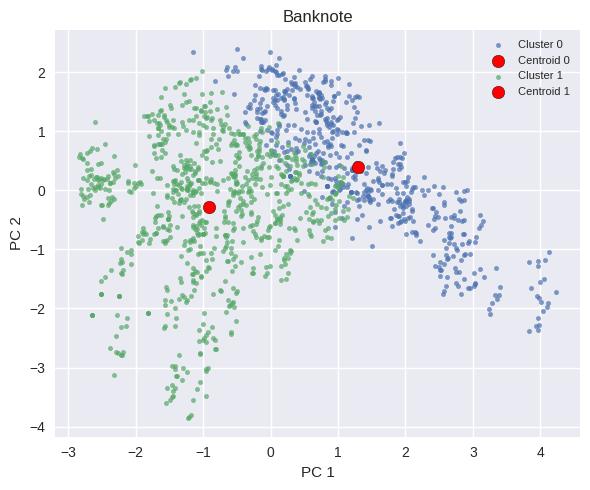

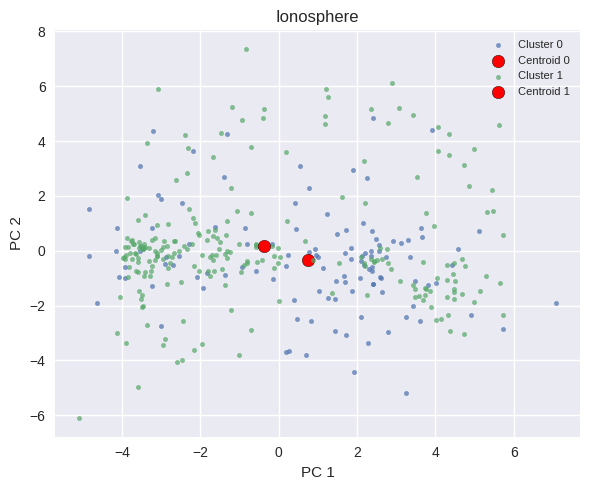

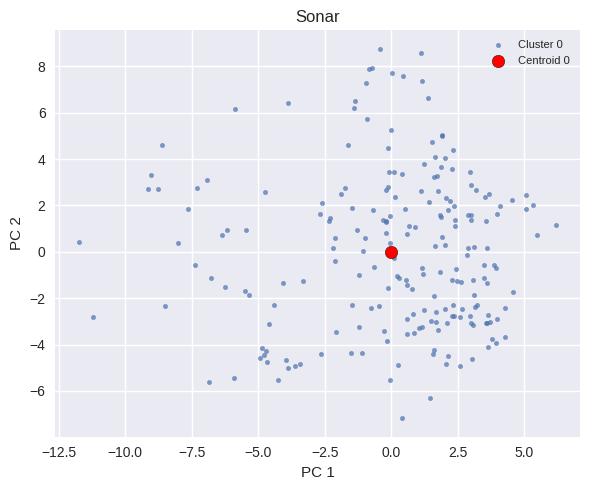

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dataset_alone(result):
    X_2d = result["X_2d"]
    y_clusters = result["y_clusters"]
    name = result["name"]

    plt.figure(figsize=(6, 5))
    unique_clusters = np.unique(y_clusters)

    for c in unique_clusters:
        mask = (y_clusters == c)

        # Cluster points
        plt.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            s=10, alpha=0.7, label=f"Cluster {c}"
        )

        # Centroid
        centroid = X_2d[mask].mean(axis=0)
        plt.scatter(
            centroid[0], centroid[1],
            color='red', marker='o', s=80, edgecolor='black',
            label=f"Centroid {c}"
        )

    plt.title(name.capitalize())
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Large datasets: banknote, ionosphere, sonar
for ds in ["banknote", "ionosphere", "sonar"]:
    plot_dataset_alone(get_res(ds))

## 9. Visualization – Medium Datasets (Blobs, Varied, Wine)

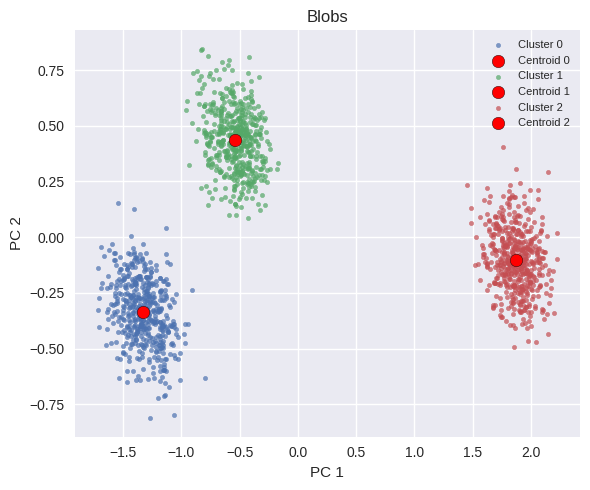

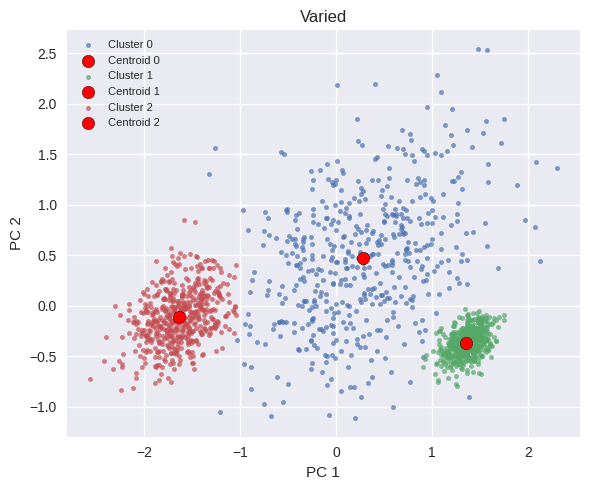

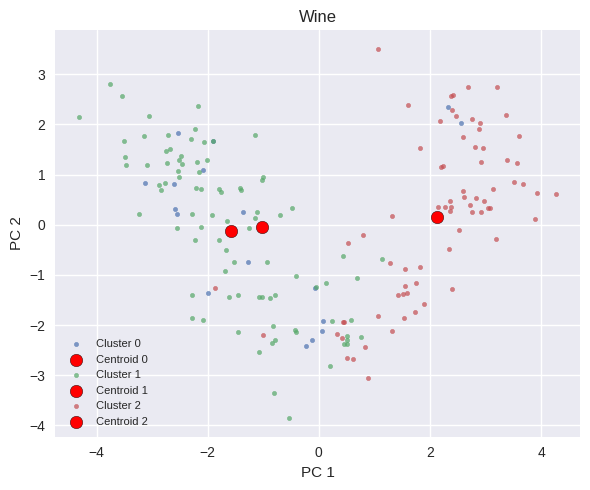

In [ ]:
def plot_dataset_alone(result):
    X_2d = result["X_2d"]
    y_clusters = result["y_clusters"]
    name = result["name"]

    plt.figure(figsize=(6, 5))
    unique_clusters = np.unique(y_clusters)

    for c in unique_clusters:
        mask = (y_clusters == c)

        # Plot cluster points
        plt.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            s=10, alpha=0.7, label=f"Cluster {c}"
        )

        # Plot centroid
        centroid = X_2d[mask].mean(axis=0)
        plt.scatter(
            centroid[0], centroid[1],
            color='red', marker='o', s=80, edgecolor='black',
            label=f"Centroid {c}"
        )

    plt.title(name.capitalize())
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ---- Plot each medium dataset alone ----
plot_dataset_alone(get_res("blobs"))
plot_dataset_alone(get_res("varied"))
plot_dataset_alone(get_res("wine"))

## 10. Visualization – Small Datasets (Flame, Glass, Iris)

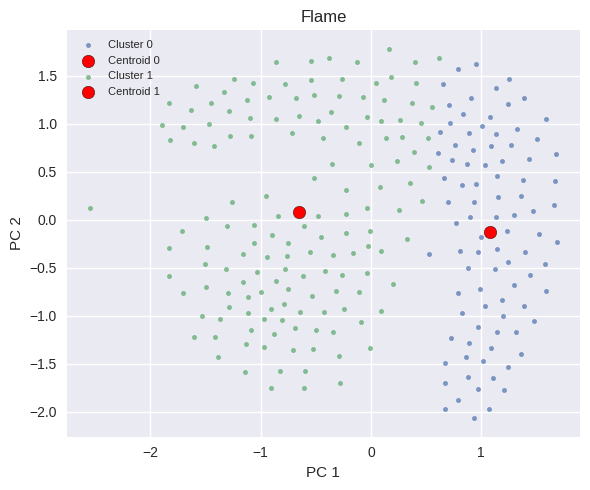

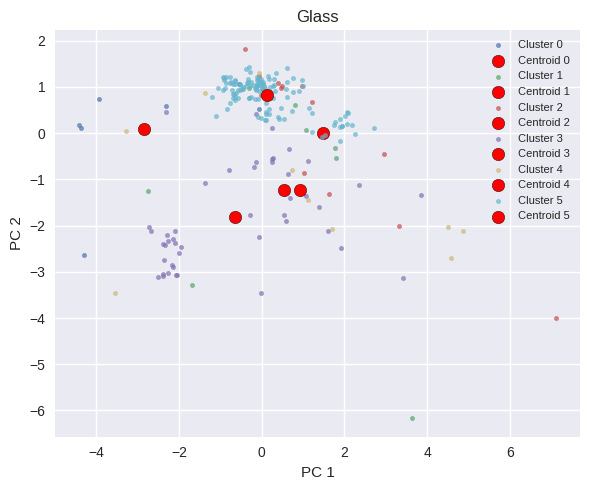

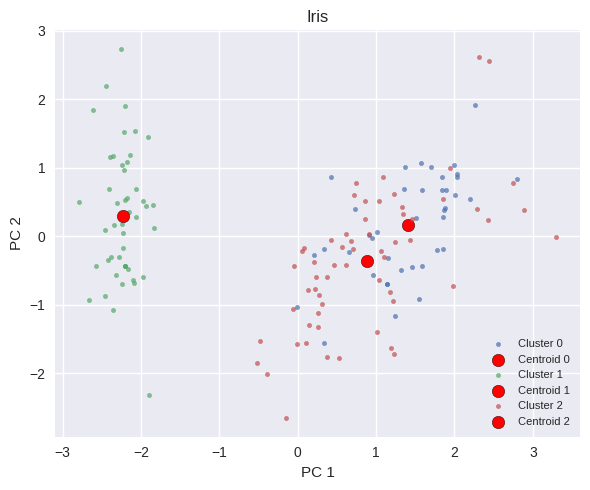

In [ ]:
# Plot each small dataset alone
plot_dataset_alone(get_res("flame"))
plot_dataset_alone(get_res("glass"))
plot_dataset_alone(get_res("iris"))

## 11. Discussion (to fill in your report)
Use the `summary_df` table and the scatter plots to compare how GMM behaves across:
- Well-separated, compact clusters (e.g., blobs, varied, wine)
- More complex or overlapping structures (e.g., flame, glass, iris)
- Higher-dimensional real datasets (banknote, ionosphere, sonar)

You can now export the figures for each group and the metrics table into your LaTeX / Word report.